First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Initial Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
C

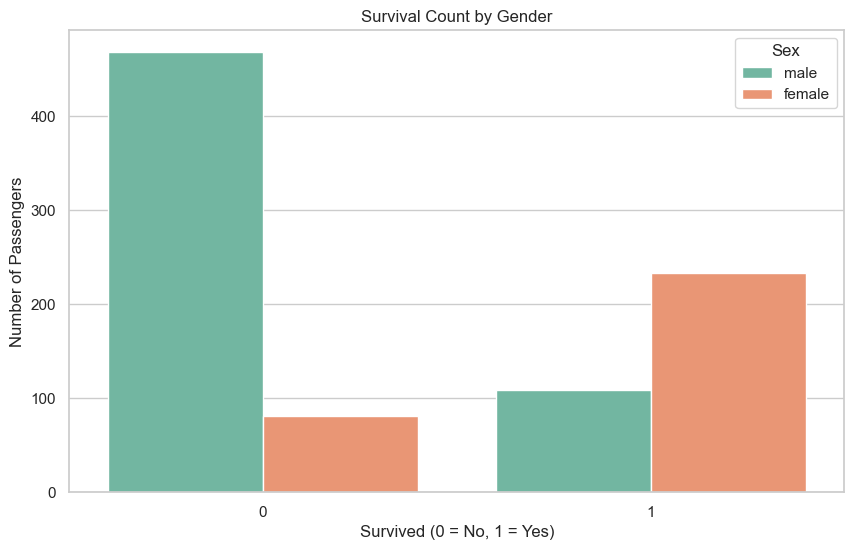

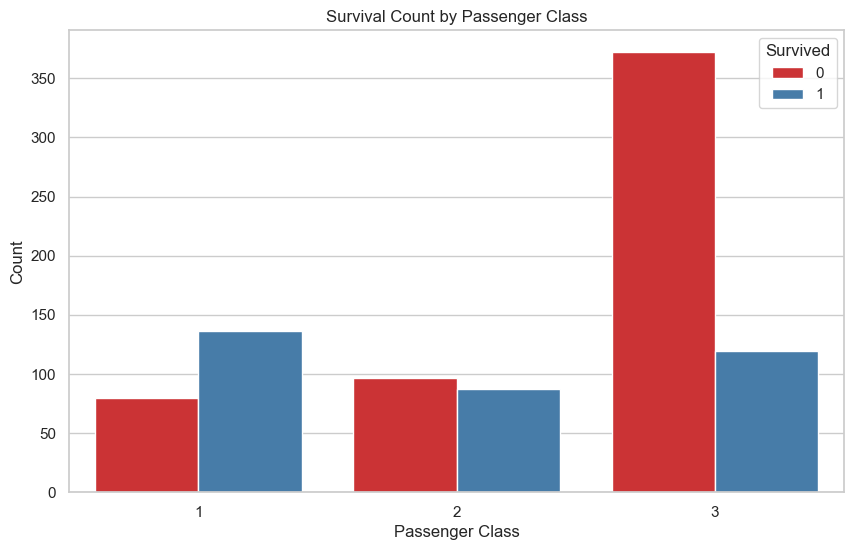

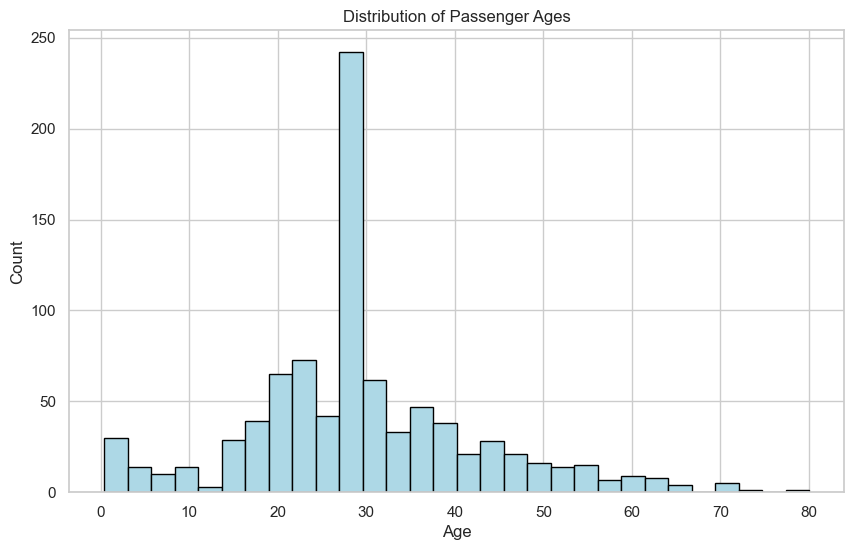

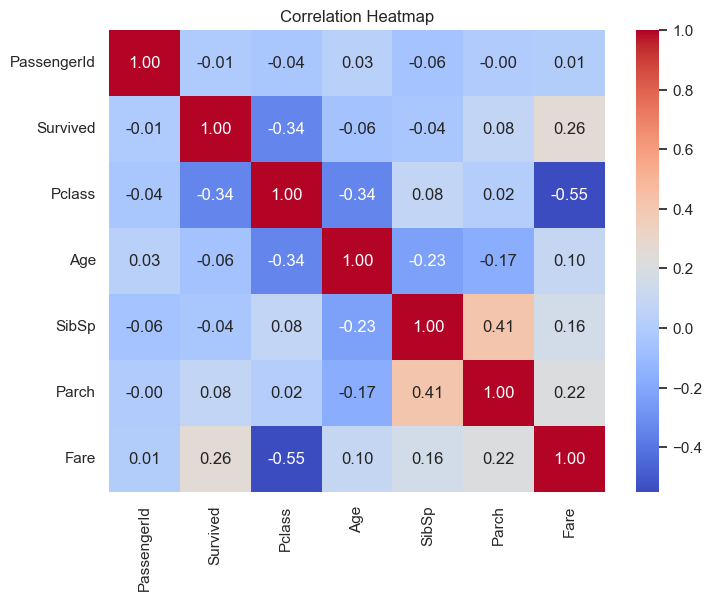


=== Survival Rate by Class ===
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

=== Survival Rate by Gender ===
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

=== Average Fare by Survival ===
Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

📌 Summary of Insights:
- Passengers in 1st class had the highest survival rate (~63%),
  while 3rd class had the lowest (~24%).
- Females had a much higher survival rate (~74%) compared to males (~19%).
- Survivors generally paid higher fares than non-survivors.
- Strong correlations observed between Fare, Pclass, and Survival.



In [17]:
# 🚢 Titanic Dataset - Exploratory Data Analysis (EDA)

# 📥 Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 📊 Load the dataset
df = pd.read_csv('Titanic-Dataset.csv')
print("First 5 rows of the dataset:")
display(df.head())

# 🧹 Data Cleaning
print("\nInitial Data Info:")
df.info()

print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Fill missing 'Age' with median (avoid inplace)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing 'Embarked' with mode (avoid inplace)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop 'Cabin' due to excessive missing values
df = df.drop(columns='Cabin')

# Drop duplicates
df = df.drop_duplicates()

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# 📈 Visualizations

# Survival by Gender
sns.countplot(data=df, x='Survived', hue='Sex', palette='Set2')
plt.title('Survival Count by Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

# Survival by Passenger Class
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set1')
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

# Histogram of Age Distribution
plt.hist(df['Age'], bins=30, color='lightblue', edgecolor='black')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 📌 Key Insights

print("\n=== Survival Rate by Class ===")
print(df.groupby('Pclass')['Survived'].mean())

print("\n=== Survival Rate by Gender ===")
print(df.groupby('Sex')['Survived'].mean())

print("\n=== Average Fare by Survival ===")
print(df.groupby('Survived')['Fare'].mean())

# 🔍 Summary (Can be added as a Markdown cell if needed)
summary = """
📌 Summary of Insights:
- Passengers in 1st class had the highest survival rate (~63%),
  while 3rd class had the lowest (~24%).
- Females had a much higher survival rate (~74%) compared to males (~19%).
- Survivors generally paid higher fares than non-survivors.
- Strong correlations observed between Fare, Pclass, and Survival.
"""
print(summary)
